In [ ]:
!pip install -q transformers datasets scikit-learn sentencepiece accelerate

In [ ]:
!pip install -q --upgrade transformers peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 32.5 MB/s eta 0:00:00


In [ ]:
!pip install sentencepiece

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!python /content/train.py \
    --model_name "google/flan-t5-base" \
    --data_path "/content/augmented_dataset.jsonl" \
    --epochs 20 \
    --per_device_train_batch_size 4 \
    --per_device_eval_batch_size 4 \
    --gradient_accumulation_steps 4 \
    --learning_rate 3e-4 \
    --early_stopping_patience 5 \
    --output_dir "/content/drive/MyDrive/SLM_FLAN_FINE_TUNED/checkypointy"


Loading and tokenizing dataset from '/content/augmented_dataset.jsonl'...
config.json: 100% 1.40k/1.40k [00:00<00:00, 5.05MB/s]
tokenizer_config.json: 100% 2.54k/2.54k [00:00<00:00, 10.1MB/s]
spiece.model: 100% 792k/792k [00:00<00:00, 995kB/s]
tokenizer.json: 100% 2.42M/2.42M [00:00<00:00, 78.8MB/s]
special_tokens_map.json: 100% 2.20k/2.20k [00:00<00:00, 2.78MB/s]
Tokenizing train split: 100% 1174/1174 [00:00<00:00, 4648.41 examples/s]
Tokenizing eval split: 100% 130/130 [00:00<00:00, 4411.77 examples/s]
Train examples: 1174
Eval examples:  130
Loading model 'google/flan-t5-base'...
model.safetensors: 100% 990M/990M [00:03<00:00, 274MB/s]
Loading weights: 100% 282/282 [00:00<00:00, 4227.09it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
gener

In [ ]:
!rm -rf /content/checkpoints

In [ ]:
import sys, torch, textwrap
sys.path.insert(0, '/content')
from inference import ProcurementExtractor, _count_products_in_email
from dataset import build_input_text, load_records
from sklearn.model_selection import train_test_split

extractor = ProcurementExtractor('/content/checkypointy/final')

records = load_records('/content/augmented_dataset.jsonl')
_, eval_records = train_test_split(records, test_size=0.1, random_state=42, shuffle=True)

rec = eval_records[0]
email = rec['email']
n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

print("GT products  :", len(rec['products']))
print("Detected count:", n)
print("\nPROMPT:\n", prompt[:300])

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
print("\noutput_ids shape:", output_ids.shape)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


GT products  : 2
Detected count: 2

PROMPT:
 Extract procurement order details as a JSON array with exactly 2 element(s). Each element has keys: product_raw_text, product_brand, product_specifications, order_qty, order_unit_of_measure. Use empty string for missing fields. Email: Dear Vendor, Please arrange 969 units of Classmate Spiral Binding

output_ids shape: torch.Size([1, 153])
DECODED: '["product_raw_text":"Classmate Spiral Binding Notebooks A5","product_brand":"Classmate","product_specifications":"Spiral Binding Notebooks A5","order_qty":"969","order_unit_of_measure":"units","product_raw_text":"Philips Hue Smart LED Bulbs","product_brand":"Philips","product_specifications":"Hue Smart LED Bulbs","order_qty":"1038","order_unit_of_measure":"units"]'


In [ ]:
import shutil
# Replace 'my_folder' with your actual folder name
shutil.make_archive('PERFECTION', 'zip', '/content/checkpoints/final')


'/content/PERFECTION.zip'

In [ ]:
from inference import _count_products_in_email

email = """Please quote your best rates along with delivery timeline for the following materials required for our project at Taloja.

1. Polycab FR Copper Cable 4 sqmm – 1,500 Mtrs
2. 2.5 sq FRLSH wire (Red) – 2,000 Mtrs
3. 1.5 sq FR wire (Yellow) – 1,200 Mtrs
4. XLPE Al Armoured Cable 3.5C x 120 sqmm – 500 Mtrs
5. Flexible wire 0.75 sqmm (Black) – 20 coils"""

print("Detected count:", _count_products_in_email(email))

Detected count: 5


In [ ]:
email = """Please quote your best rates along with delivery timeline for the following materials required for our project at Taloja.

1. Polycab FR Copper Cable 4 sqmm – 1,500 Mtrs
2. 2.5 sq FRLSH wire (Red) – 2,000 Mtrs
3. 1.5 sq FR wire (Yellow) – 1,200 Mtrs
4. XLPE Al Armoured Cable 3.5C x 120 sqmm – 500 Mtrs
5. Flexible wire 0.75 sqmm (Black) – 20 coils"""

# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"Polycab FR Copper Cable 4 sqmm","product_brand":"Polycab","product_specifications":"FR Copper Cable 4 sqmm","order_qty":"1500","order_unit_of_measure":"Mtrs","product_raw_text":"2.5 sq FRLSH wire (Red)","product_brand":"","product_specifications":"2.5 sq FRLSH wire (Red)","order_qty":"2000","order_unit_of_measure":"Mtrs","product_raw_text":"1.5 sq FR wire (Yellow)","product_brand":"","product_specifications":"1.5 sq FR wire (Yellow)","order_qty":"1200","order_unit_of_measure":"Mtrs","product_raw_text":"XLPE Al Armoured Cable 3.5C x 120 sqmm","product_brand":"","product_specifications":"XLPE Al Armoured Cable 3.5C x 120 sqmm","order_qty":"500","order_unit_of_measure":"Mtrs","product_raw_text":"Flexible wire 0.75 sqmm (Black)","product_brand":"","product_specifications":"Flexible wire 0.75 sqmm (Black)","order_qty":"20","order_unit_of_measure":"coils"]'


In [ ]:
import shutil
shutil.move('/content/checkpoints', '/content/drive/MyDrive/PERFECTION')

'/content/drive/MyDrive/PERFECTION/checkpoints'

In [ ]:
shutil.copy('/content/inference.py', '/content/drive/MyDrive/PERFECTION')


'/content/drive/MyDrive/PERFECTION/inference.py'

In [ ]:
shutil.copy('/content/dataset.py', '/content/drive/MyDrive/PERFECTION')


'/content/drive/MyDrive/PERFECTION/dataset.py'

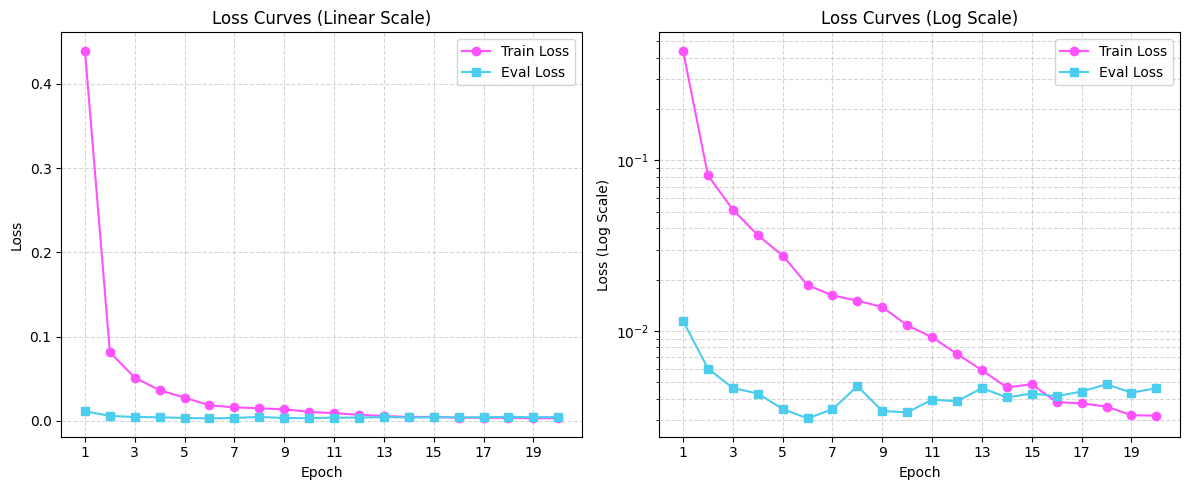

In [ ]:
import matplotlib.pyplot as plt

# Data from training log
epochs = list(range(1, 21))
train_loss = [
    0.4395, 0.08157, 0.05141, 0.03641, 0.02765,
    0.01856, 0.01614, 0.01504, 0.0138, 0.01078,
    0.009181, 0.007321, 0.005883, 0.004662, 0.004864,
    0.003822, 0.003756, 0.003601, 0.003204, 0.003182
]
eval_loss = [
    0.01145, 0.006013, 0.004626, 0.004293, 0.003482,
    0.003071, 0.003468, 0.004744, 0.00339, 0.00333,
    0.003957, 0.003868, 0.004618, 0.004075, 0.004291,
    0.004143, 0.004412, 0.004863, 0.004345, 0.004608
]

# Set up side-by-side subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Linear Scale Plot
ax1.plot(epochs, train_loss, label='Train Loss', marker='o', color='#ff52ff')
ax1.plot(epochs, eval_loss, label='Eval Loss', marker='s', color='#4ccded')
ax1.set_title('Loss Curves (Linear Scale)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(range(1, 21, 2))
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# 2. Log Scale Plot
ax2.plot(epochs, train_loss, label='Train Loss', marker='o', color='#ff52ff')
ax2.plot(epochs, eval_loss, label='Eval Loss', marker='s', color='#4ccded')
ax2.set_yscale('log')
ax2.set_title('Loss Curves (Log Scale)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Log Scale)')
ax2.set_xticks(range(1, 21, 2))
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig('loss_plot_combined.png')

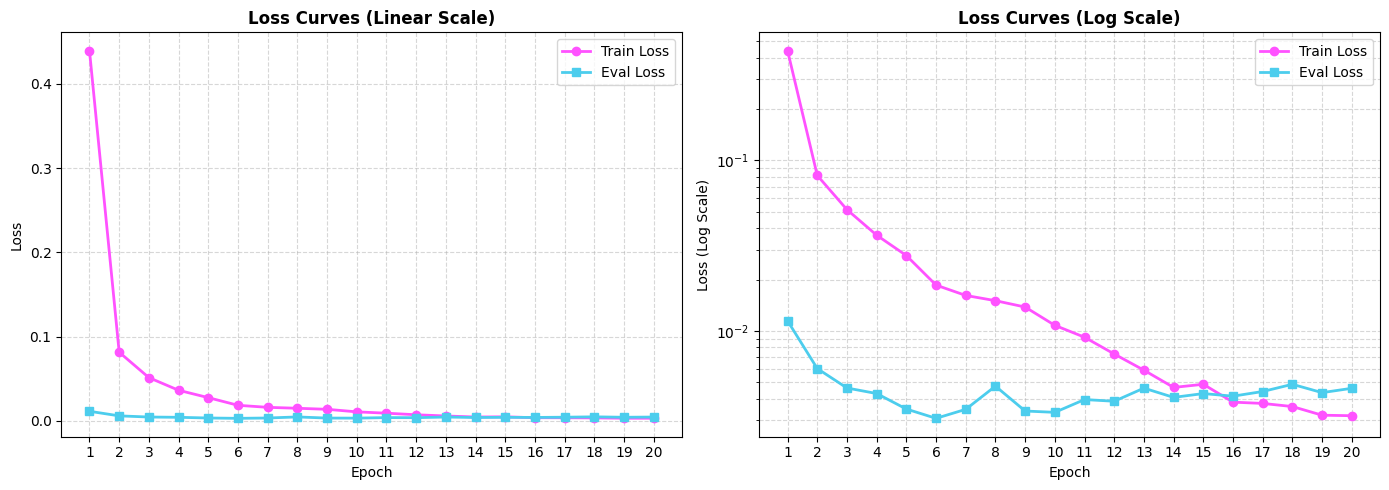

In [ ]:
import re
import matplotlib.pyplot as plt

# Your log string containing the epoch updates
log_data = """
{'loss': '0.4395', 'grad_norm': '1.368', 'learning_rate': '0.0002852', 'epoch': '1'}
{'eval_loss': '0.01145', 'eval_runtime': '1.779', 'eval_samples_per_second': '73.08', 'eval_steps_per_second': '18.55', 'epoch': '1'}
{'loss': '0.08157', 'grad_norm': '0.4368', 'learning_rate': '0.0002702', 'epoch': '2'}
{'eval_loss': '0.006013', 'eval_runtime': '1.76', 'eval_samples_per_second': '73.88', 'eval_steps_per_second': '18.75', 'epoch': '2'}
{'loss': '0.05141', 'grad_norm': '0.2617', 'learning_rate': '0.0002552', 'epoch': '3'}
{'eval_loss': '0.004626', 'eval_runtime': '1.768', 'eval_samples_per_second': '73.52', 'eval_steps_per_second': '18.66', 'epoch': '3'}
{'loss': '0.03641', 'grad_norm': '0.1511', 'learning_rate': '0.0002402', 'epoch': '4'}
{'eval_loss': '0.004293', 'eval_runtime': '1.764', 'eval_samples_per_second': '73.72', 'eval_steps_per_second': '18.71', 'epoch': '4'}
{'loss': '0.02765', 'grad_norm': '0.7735', 'learning_rate': '0.0002252', 'epoch': '5'}
{'eval_loss': '0.003482', 'eval_runtime': '1.782', 'eval_samples_per_second': '72.97', 'eval_steps_per_second': '18.52', 'epoch': '5'}
{'loss': '0.01856', 'grad_norm': '0.3436', 'learning_rate': '0.0002102', 'epoch': '6'}
{'eval_loss': '0.003071', 'eval_runtime': '1.763', 'eval_samples_per_second': '73.73', 'eval_steps_per_second': '18.72', 'epoch': '6'}
{'loss': '0.01614', 'grad_norm': '0.1853', 'learning_rate': '0.0001952', 'epoch': '7'}
{'eval_loss': '0.003468', 'eval_runtime': '1.8', 'eval_samples_per_second': '72.22', 'eval_steps_per_second': '18.33', 'epoch': '7'}
{'loss': '0.01504', 'grad_norm': '0.3386', 'learning_rate': '0.0001802', 'epoch': '8'}
{'eval_loss': '0.004744', 'eval_runtime': '1.775', 'eval_samples_per_second': '73.26', 'eval_steps_per_second': '18.6', 'epoch': '8'}
{'loss': '0.0138', 'grad_norm': '0.07193', 'learning_rate': '0.0001652', 'epoch': '9'}
{'eval_loss': '0.00339', 'eval_runtime': '1.77', 'eval_samples_per_second': '73.43', 'eval_steps_per_second': '18.64', 'epoch': '9'}
{'loss': '0.01078', 'grad_norm': '0.4564', 'learning_rate': '0.0001502', 'epoch': '10'}
{'eval_loss': '0.00333', 'eval_runtime': '1.757', 'eval_samples_per_second': '73.99', 'eval_steps_per_second': '18.78', 'epoch': '10'}
{'loss': '0.009181', 'grad_norm': '0.2669', 'learning_rate': '0.0001352', 'epoch': '11'}
{'eval_loss': '0.003957', 'eval_runtime': '1.764', 'eval_samples_per_second': '73.7', 'eval_steps_per_second': '18.71', 'epoch': '11'}
{'loss': '0.007321', 'grad_norm': '0.02306', 'learning_rate': '0.0001202', 'epoch': '12'}
{'eval_loss': '0.003868', 'eval_runtime': '1.76', 'eval_samples_per_second': '73.86', 'eval_steps_per_second': '18.75', 'epoch': '12'}
{'loss': '0.005883', 'grad_norm': '0.005497', 'learning_rate': '0.0001052', 'epoch': '13'}
{'eval_loss': '0.004618', 'eval_runtime': '1.761', 'eval_samples_per_second': '73.81', 'eval_steps_per_second': '18.74', 'epoch': '13'}
{'loss': '0.004662', 'grad_norm': '0.8196', 'learning_rate': '9.02e-05', 'epoch': '14'}
{'eval_loss': '0.004075', 'eval_runtime': '1.786', 'eval_samples_per_second': '72.77', 'eval_steps_per_second': '18.47', 'epoch': '14'}
{'loss': '0.004864', 'grad_norm': '0.00732', 'learning_rate': '7.52e-05', 'epoch': '15'}
{'eval_loss': '0.004291', 'eval_runtime': '1.775', 'eval_samples_per_second': '73.22', 'eval_steps_per_second': '18.59', 'epoch': '15'}
{'loss': '0.003822', 'grad_norm': '1.288', 'learning_rate': '6.02e-05', 'epoch': '16'}
{'eval_loss': '0.004143', 'eval_runtime': '1.768', 'eval_samples_per_second': '73.51', 'eval_steps_per_second': '18.66', 'epoch': '16'}
{'loss': '0.003756', 'grad_norm': '0.2805', 'learning_rate': '4.52e-05', 'epoch': '17'}
{'eval_loss': '0.004412', 'eval_runtime': '1.761', 'eval_samples_per_second': '73.81', 'eval_steps_per_second': '18.74', 'epoch': '17'}
{'loss': '0.003601', 'grad_norm': '0.6178', 'learning_rate': '3.02e-05', 'epoch': '18'}
{'eval_loss': '0.004863', 'eval_runtime': '1.767', 'eval_samples_per_second': '73.56', 'eval_steps_per_second': '18.67', 'epoch': '18'}
{'loss': '0.003204', 'grad_norm': '0.04793', 'learning_rate': '1.52e-05', 'epoch': '19'}
{'eval_loss': '0.004345', 'eval_runtime': '1.782', 'eval_samples_per_second': '72.97', 'eval_steps_per_second': '18.52', 'epoch': '19'}
{'loss': '0.003182', 'grad_norm': '0.01254', 'learning_rate': '2.027e-07', 'epoch': '20'}
{'eval_loss': '0.004608', 'eval_runtime': '1.761', 'eval_samples_per_second': '73.83', 'eval_steps_per_second': '18.74', 'epoch': '20'}
"""

# Extract values using regex parsing
epochs = []
train_losses = []
eval_losses = []

# Find training loss logs
for match in re.finditer(r"'loss': '([\d.]+)',.*?'epoch': '(\d+)'", log_data):
    train_losses.append(float(match.group(1)))
    epochs.append(int(match.group(2)))

# Find evaluation loss logs
for match in re.finditer(r"'eval_loss': '([\d.]+)'", log_data):
    eval_losses.append(float(match.group(1)))

# Initialize the plot layout (2 subplots side-by-side)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Standard Linear Scale
ax1.plot(epochs, train_losses, label='Train Loss', marker='o', linewidth=2, color='#ff52ff')
ax1.plot(epochs, eval_losses, label='Eval Loss', marker='s', linewidth=2, color='#4ccded')
ax1.set_title('Loss Curves (Linear Scale)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(range(1, 21))
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Plot 2: Log Scale (Better visualization for the late-epoch details)
ax2.plot(epochs, train_losses, label='Train Loss', marker='o', linewidth=2, color='#ff52ff')
ax2.plot(epochs, eval_losses, label='Eval Loss', marker='s', linewidth=2, color='#4ccded')
ax2.set_yscale('log')
ax2.set_title('Loss Curves (Log Scale)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss (Log Scale)')
ax2.set_xticks(range(1, 21))
ax2.grid(True, which="both", linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install sentencepiece

In [ ]:
import sys, torch, textwrap
sys.path.insert(0, '/content')
from inference import ProcurementExtractor, _count_products_in_email
from dataset import build_input_text, load_records
from sklearn.model_selection import train_test_split

extractor = ProcurementExtractor('/content/drive/MyDrive/SLM_FLAN_FINE_TUNED/checkypointy/final')

records = load_records('/content/augmented_dataset.jsonl')
_, eval_records = train_test_split(records, test_size=0.1, random_state=42, shuffle=True)

rec = eval_records[0]
email = rec['email']
n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

print("GT products  :", len(rec['products']))
print("Detected count:", n)
print("\nPROMPT:\n", prompt[:300])

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
print("\noutput_ids shape:", output_ids.shape)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


GT products  : 2
Detected count: 2

PROMPT:
 Extract procurement order details as a JSON array with exactly 2 element(s). Each element has keys: product_raw_text, product_brand, product_specifications, order_qty, order_unit_of_measure. Use empty string for missing fields. Email: Dear Vendor, Please arrange 969 units of Classmate Spiral Binding

output_ids shape: torch.Size([1, 153])
DECODED: '["product_raw_text":"Classmate Spiral Binding Notebooks A5","product_brand":"Classmate","product_specifications":"Spiral Binding Notebooks A5","order_qty":"969","order_unit_of_measure":"units","product_raw_text":"Philips Hue Smart LED Bulbs","product_brand":"Philips","product_specifications":"Hue Smart LED Bulbs","order_qty":"1038","order_unit_of_measure":"units"]'


In [ ]:
email = """Please quote your best rates along with delivery timeline for the following materials required for our project at Taloja.

1. Polycab FR Copper Cable 4 sqmm – 1,500 Mtrs
2. 2.5 sq FRLSH wire (Red) – 2,000 Mtrs
3. 1.5 sq FR wire (Yellow) – 1,200 Mtrs
4. XLPE Al Armoured Cable 3.5C x 120 sqmm – 500 Mtrs
5. Flexible wire 0.75 sqmm (Black) – 20 coils"""

# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
print(inputs)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
print(output_ids)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

{'input_ids': tensor([[18742, 19339,   455,  1030,    38,     3,     9,   446, 10466,  5590,
            28,  1776,   305,  3282,   599,     7,   137,  1698,  3282,    65,
          9060,    10,   556,   834, 10936,   834,  6327,     6,   556,   834,
         12164,     6,   556,   834,  9500,  1628,     6,   455,   834,  1824,
            17,    63,     6,   455,   834, 15129,   834,   858,   834, 31038,
             5,  2048,  6364,  6108,    21,  3586,  4120,     5,  8601,    10,
           863,  5035,    39,   200,  1917,   590,    28,  1929, 13618,    21,
             8,   826,  1397,   831,    21,    69,   516,    44, 11350,    32,
          1191,     5,  1300,  7945, 10891,     3,  7422, 19756, 17240,   314,
         11820,   635,     3,   104,  1914,  2560,   283,    17,    52,     7,
          1682, 10603, 11820,   377, 12831,  9122,  4107,    41,  1649,    26,
            61,     3,   104,     3,  8630,   283,    17,    52,     7,  1877,
          8613, 11820,     3,  7422,  

In [ ]:
email = """can u please send me 3kgs of bananas, 75 ton of steel and 45 L of arsenic"""

# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"bananas","product_brand":"","product_specifications":"bananas","order_qty":"3kgs","order_unit_of_measure":"kgs","product_raw_text":"steel","product_brand":"","product_specifications":"steel","order_qty":"75","order_unit_of_measure":"ton","product_raw_text":"arsenic","product_brand":"","product_specifications":"arsenic","order_qty":"45","order_unit_of_measure":"L"]'


In [ ]:
s = '["product_raw_text":"bananas","product_brand":"","product_specifications":"bananas","order_qty":"3kgs","order_unit_of_measure":"kgs","product_raw_text":"steel","product_brand":"","product_specifications":"steel","order_qty":"75","order_unit_of_measure":"ton","product_raw_text":"arsenic","product_brand":"","product_specifications":"arsenic","order_qty":"45","order_unit_of_measure":"L"]'

# remove [ ]
s = s.strip("[]")

# split into alternating keys and values
parts = s.replace('"', '').split(',')

pairs = []
for p in parts:
    key, value = p.split(':', 1)
    pairs.append((key, value))

# group every 5 fields into one item
items = []
for i in range(0, len(pairs), 5):
    item = dict(pairs[i:i+5])
    items.append(item)

print(items)

[{'product_raw_text': 'bananas', 'product_brand': '', 'product_specifications': 'bananas', 'order_qty': '3kgs', 'order_unit_of_measure': 'kgs'}, {'product_raw_text': 'steel', 'product_brand': '', 'product_specifications': 'steel', 'order_qty': '75', 'order_unit_of_measure': 'ton'}, {'product_raw_text': 'arsenic', 'product_brand': '', 'product_specifications': 'arsenic', 'order_qty': '45', 'order_unit_of_measure': 'L'}]


In [ ]:
email = """can u please send me three Watermelons of bananas, 75 ton of steel and 45 L of arsenic"""

# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"Watermelons of bananas","product_brand":"Watermelons","product_specifications":"bananas","order_qty":"3","order_unit_of_measure":"Watermelons","product_raw_text":"steel","product_brand":"Steel","product_specifications":"Bananas","order_qty":"75","order_unit_of_measure":"ton","product_raw_text":"arsenic","product_brand":"arsenic","product_specifications":"arsenic","order_qty":"45","order_unit_of_measure":"L"]'


In [ ]:
email = """3 pennies worth of juice"""
# THIS IS A GOOD EXAMPLE
# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"3 pennies worth of juice","product_brand":"","product_specifications":"3 pennies worth of juice","order_qty":"3","order_unit_of_measure":"pennies"]'


In [ ]:
email = """can u please send me -50 pipes and 20 gloves, - 9 BOATS"""
# THIS IS A BAD EXAMPLE
# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"50 pipes","product_brand":"","product_specifications":"50 pipes","order_qty":"50","order_unit_of_measure":"pipes","product_raw_text":"20 gloves","product_brand":"","product_specifications":"20 gloves","order_qty":"9","order_unit_of_measure":"BOATS"]'


In [ ]:
email = """hahha okmg this is so funny"""
# THIS IS A BAD EXAMPLE
# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"hahha okmg","product_brand":"hahha","product_specifications":"okmg","order_qty":"hahha","order_unit_of_measure":"units"]'


In [ ]:
email = """3 is what i need"""
# THIS IS A BAD EXAMPLE OF HALLUCINATION
# See raw model output first
from dataset import build_input_text
from inference import _count_products_in_email

n = _count_products_in_email(email)
prompt = build_input_text(email, n_products=n)

inputs = extractor.tokenizer(prompt, return_tensors="pt", truncation=True, max_length=4092).to(extractor.device)
print(inputs)
output_ids = extractor.model.generate(**inputs, max_new_tokens=512, num_beams=5)
print(output_ids)
decoded = extractor.tokenizer.decode(output_ids[0], skip_special_tokens=True)
print("DECODED:", repr(decoded))

DECODED: '["product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_brand":"product_brand","product_specifications":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_raw_text":"product_brand":"pro

In [ ]:
s = decoded

# remove [ ]
s = s.strip("[]")

# split into alternating keys and values
parts = s.replace('"', '').split(',')

pairs = []
for p in parts:
    key, value = p.split(':', 1)
    pairs.append((key, value))

# group every 5 fields into one item
items = []
for i in range(0, len(pairs), 5):
    item = dict(pairs[i:i+5])
    items.append(item)

print(items)

[{'product_raw_text': '3 pennies worth of juice', 'product_brand': '', 'product_specifications': '3 pennies worth of juice', 'order_qty': '3', 'order_unit_of_measure': 'pennies'}]


In [8]:
!python /content/drive/MyDrive/SLM_FLAN_FINE_TUNED/evaluate.py \
--model_dir /content/drive/MyDrive/SLM_FLAN_FINE_TUNED/checkypointy/final \
        --data_path /content/drive/MyDrive/SLM_FLAN_FINE_TUNED/augmented_dataset.jsonl \
        --split eval \
        --output_report eval_report.json

Loading model from '/content/drive/MyDrive/SLM_FLAN_FINE_TUNED/checkypointy/final'...
Loading weights: 100% 282/282 [00:23<00:00, 11.82it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
Model loaded on: cuda
Loading dataset from '/content/drive/MyDrive/SLM_FLAN_FINE_TUNED/augmented_dataset.jsonl'...
Evaluating on 131 'eval' records...

  ...25/131 processed
  ...50/131 processed
  ...75/131 processed
  ...100/131 processed
  ...125/131 processed

EVALUATION REPORT
Records evaluated      : 131
Product count accuracy : 100.0%
Exact-match accuracy   : 87.8%

Micro-avg  Precision: 0.9845  Recall: 0.9845  F1: 0.9845
Macro-avg F1: 0.9845

Field                        Precision    Recall        F1
------------------------------------------------------

In [4]:
!pip install -q transformers datasets scikit-learn sentencepiece accelerate

In [6]:
!pip install sentencepiece --upgrade